#**Definición del Espacio de Probabilidad**

---



*Un espacio de probabilidad es el modelo matemático diseñado para estudiar formalmente un experimento aleatorio.*


---




Para estudiar un fenómeno aleatorio de forma rigurosa, en 1933 el matemático ruso Andrei Kolmogorov propuso modelarlo a través de una terna matemática llamada espacio de probabilidad, denotada como (Ω,F,P)
. Cada elemento de esta terna tiene un propósito específico:

**Espacio muestral ($\Omega$):** Es el conjunto de todos los posibles resultados individuales de un experimento aleatorio.

*A cada resultado particular se le denota usualmente con la letra griega $\omega$.*

**Eventos ($\mathcal{F}$):** Un evento es cualquier subconjunto del espacio muestral al que le queremos calcular una probabilidad, por ejemplo: que el dado caiga en un número par (A={2,4,6})

No basta con tener los resultados sueltos; necesitamos agruparlos lógica y matemáticamente. La $\sigma$-álgebra asegura que si sabemos la probabilidad de un evento A, automáticamente podemos calcular la de su negación o complemento Ac(que no ocurra A), y que si tenemos varios eventos, podemos calcular la probabilidad de su unión

El conjunto $\mathcal{F}$ representa una familia ($\sigma$-álgebra) que agrupa a todos estos subconjuntos de interés a los cuales se les puede asignar una probabilidad.

**Medida de Probabilidad ($P$):** Es una función que asigna a cada evento un número real en el intervalo $[0, 1]$, indicando qué tan posible es que ocurra.

Para que sea válida, debe cumplir con los Axiomas de Kolmogorov:

1. **No negatividad:** Para cualquier evento $A$, su probabilidad no es negativa:$$P(A) \ge 0$$
2. **Normalización:** La probabilidad de que ocurra algún resultado en todo el espacio muestral es la unidad:$$P(\Omega) = 1$$

3. **$\sigma$-aditividad:** Para cualquier sucesión finita o infinita de eventos mutuamente excluyentes (es decir, que no tienen elementos en común, $A_i \cap A_j = \emptyset$ para todo $i \neq j$), la probabilidad de la unión de todos ellos es la suma de sus probabilidades individuales:

$$P\left(\bigcup_{n=1}^{\infty} A_n\right) = \sum_{n=1}^{\infty} P(A_n)$$




# **Ejemplo: Lanzamiento de un dado 🎲**

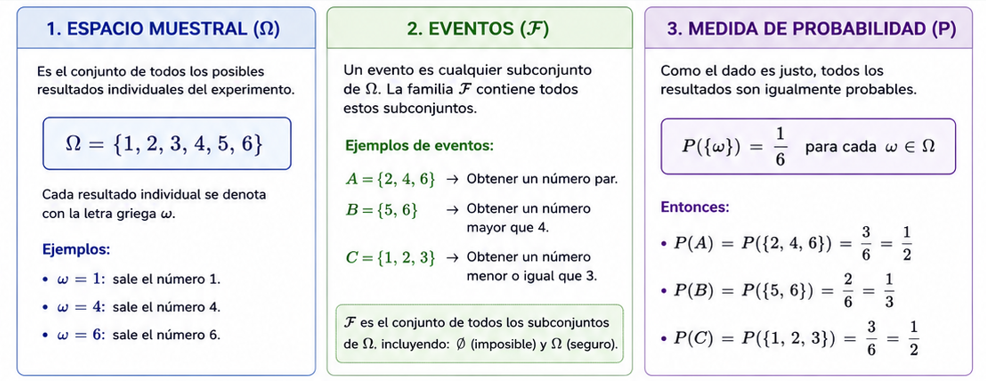

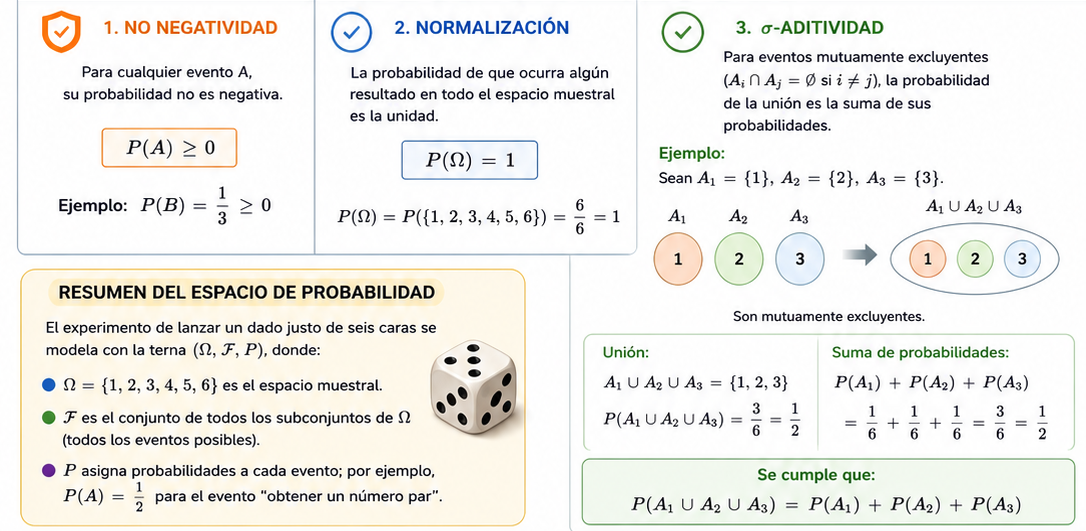

# **Probabilidad Condicional e Independencia**


---



**Probabilidad Condicional:** A menudo, la información adicional cambia nuestras expectativas sobre un experimento.

La probabilidad condicional del evento $A$, dado que ha ocurrido el evento $B$, se denota por $P(A \mid B)$ y se define como el cociente:

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}$$bajo la condición rigurosa de que $P(B) > 0$.

Al saber que el evento B ya ocurrió, nuestro universo original Ω se encoge y ahora nuestro nuevo universo es B.
Por eso dividimos entre P(B). Si tiramos un dado y alguien nos "sopla" que cayó un número par (B={2,4,6}), la probabilidad de que haya sido un 2 (A={2}) ya no es 1/6 respecto a todo el dado, sino 1/3 respecto a nuestro nuevo universo

**Independencia de Eventos:** Se dice que dos eventos $A$ y $B$ son independientes si la ocurrencia de uno no afecta la probabilidad de ocurrencia del otro.

Matemáticamente se define cuando se cumple la igualdad:

$$P(A \cap B) = P(A)P(B)$$

Equivalentemente, si $P(B) > 0$, ocurre cuando $P(A \mid B) = P(A)$.

*Es un error común confundir "independientes" con "mutuamente excluyentes"
. Mutuamente excluyentes significa que si ocurre uno, el otro es imposible que ocurra (están altamente condicionados)
. Independientes significa que el primer evento no aporta ninguna información sobre el segundo, como lanzar una moneda dos veces seguidas.*

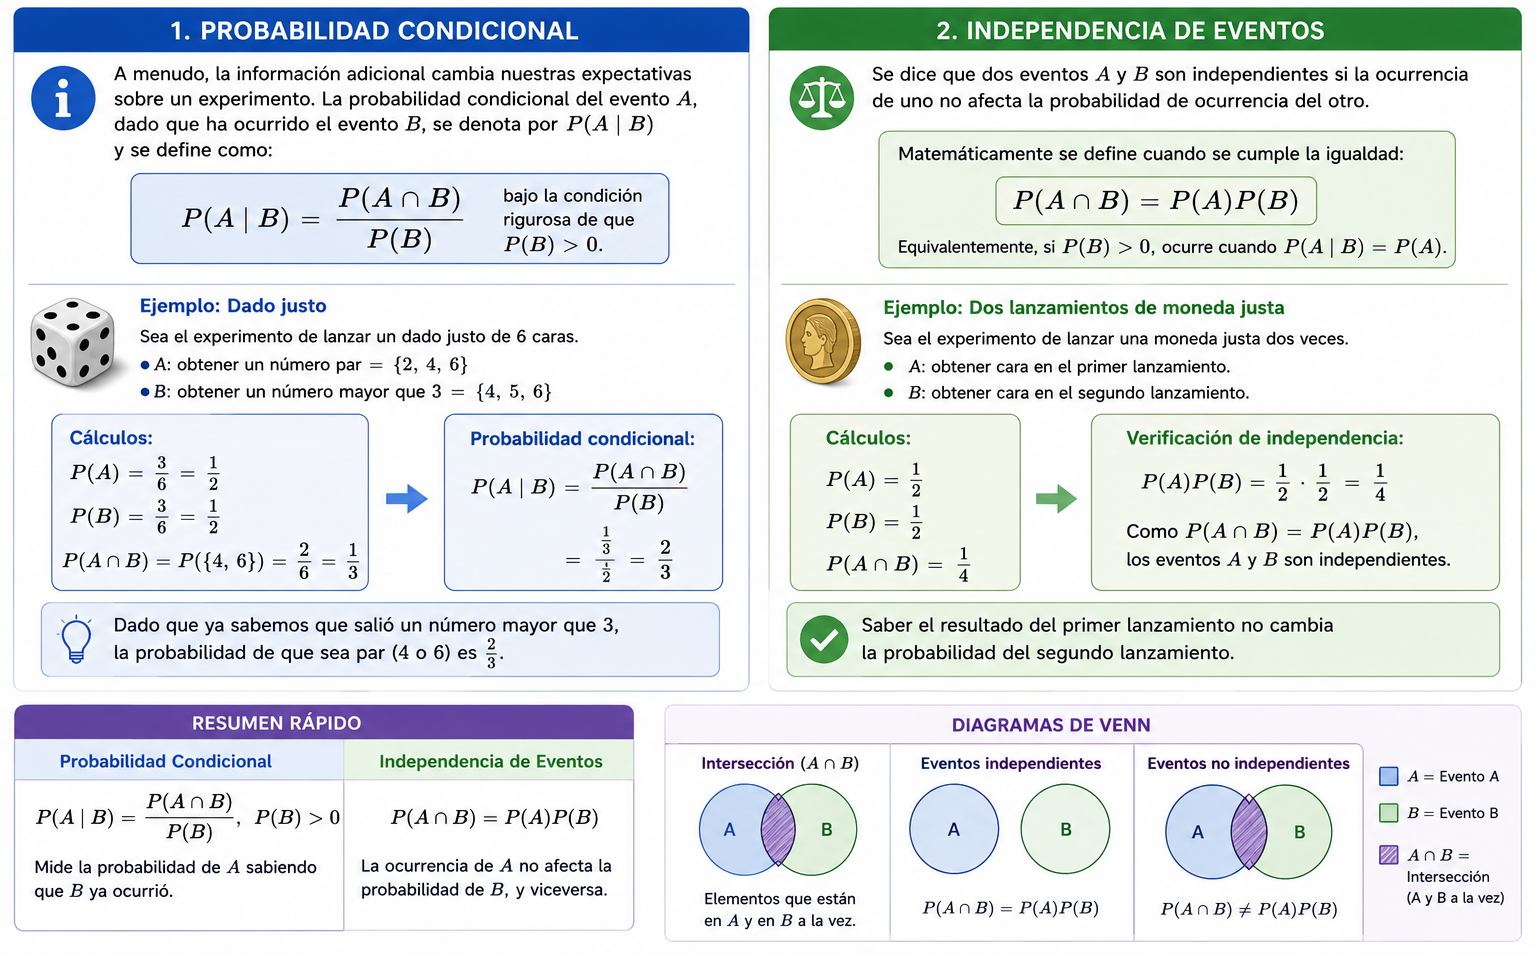

# **Enfoques de Probabilidad**

---



In [7]:
#Improtación de las librerias para los ejemplos
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from fractions import Fraction

# **Enfoque Clásico o Laplaciano**

Formalizado por Pierre-Simon Laplace en 1812, se usa cuando el espacio muestral es finito y todos los resultados tienen exactamente el mismo "peso" o probabilidad (equiprobabilidad) Se define como:
$$P(A) = \frac{\text{casos favorables}}{\text{casos totales}} = \frac{\vert{}A\vert{}}{\vert{}\Omega\vert{}}$$

**Ejemplo volado:** Considera el experimento aleatorio de lanzar una moneda equilibrada 3 veces de manera independiente. El espacio muestral $\Omega$ está compuesto por $2^3 = 8$ resultados posibles, por ejemplo $\Omega = \{(S,S,S), (S,A,S), \dots\}$. Calculemos la probabilidad del evento $A$: "que todos los resultados sean Águila".

In [8]:
# Creación del espacio muestral
Omega_volado = set(product({"A", "S"}, repeat=3))
print("Casos totales:", len(Omega_volado))

# Evento A: todas son águila
Evento_A = {om for om in Omega_volado if om.count("A") == 3}

# Cálculo clásico
prob_A = Fraction(len(Evento_A), len(Omega_volado))
print("Probabilidad Clásica de Águilas:", prob_A)

Casos totales: 8
Probabilidad Clásica de Águilas: 1/8


# **Enfoque Frecuentista**

Cuando no podemos asegurar la equiprobabilidad, por ejemplo, una moneda alterada o cargada, acudimos a la experimentación.

Se define la probabilidad como el valor hacia el cual se estabiliza la frecuencia relativa de un evento después de repetir el experimento muchísimas veces (n→∞) Se representa como:

$$P(A) = \lim_{n \to \infty} \frac{n_A}{n}$$

donde $n_A$ es el número de ocurrencias del evento en $n$ intentos.

Simulación de la Ley de los Grandes Números:

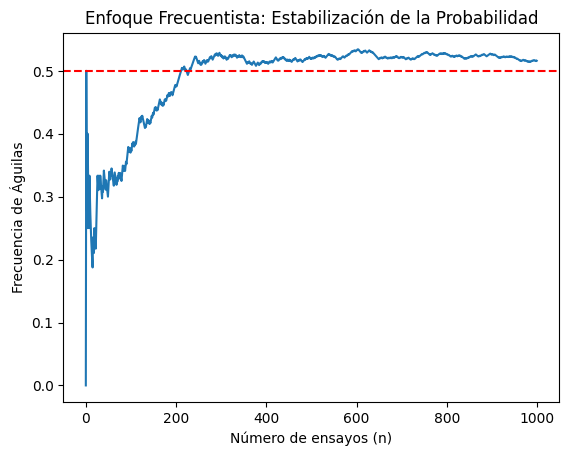

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Simulando lanzamientos de un volado para probar el enfoque frecuentista
lanzamientos = 1000
resultados = np.random.choice([1, 0], size=lanzamientos) # 1 es Águila, 0 es Sol
frecuencias_relativas = np.cumsum(resultados) / np.arange(1, lanzamientos + 1)

plt.plot(frecuencias_relativas)
plt.axhline(0.5, color='r', linestyle='--')
plt.title("Enfoque Frecuentista: Estabilización de la Probabilidad")
plt.xlabel("Número de ensayos (n)")
plt.ylabel("Frecuencia de Águilas")
plt.show()

# **Enfoque Geométrico**

Si el espacio muestral es continuo (infinitos resultados posibles, como el tiempo o la longitud), ya no podemos contar "casos" individuales. La probabilidad se convierte en la proporción de medidas geométricas:

$$P(A) = \frac{\text{Área de } A}{\text{Área de } \Omega}$$

**Problema del encuentro:** Dos amigos deciden encontrarse entre las 12:00 y las 13:00 hrs. Llegan al azar y esperarán solo 10 minutos al otro. El espacio muestral $\Omega$ es un cuadrado de $60 \times 60$ minutos (área de $3600$). El encuentro ocurre (evento $A$) si la diferencia de sus tiempos de llegada es $\vert{}x - y\vert{} \le 10$. El área favorable es una franja central cuyo tamaño es $60^2 - 50^2 = 1100$. Por lo tanto, la probabilidad es:

$$P(A) = \frac{1100}{3600} = \frac{11}{36}$$

Probabilidad Teórica (11/36): 0.3056


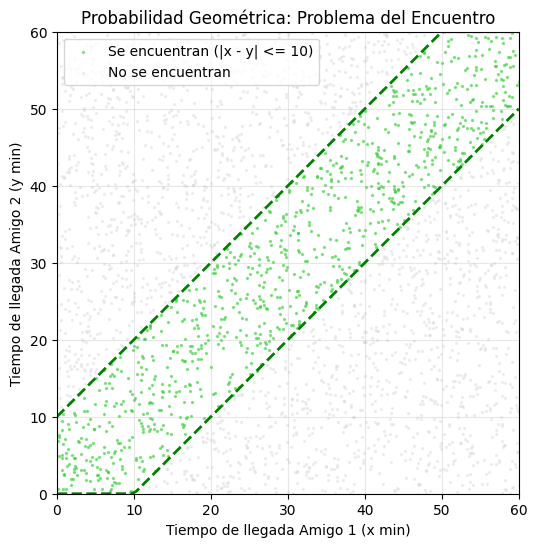

In [10]:
np.random.seed(42) # Semilla para resultados reproducibles
n_simulaciones = 100000

# Tiempos de llegada aleatorios entre 0 y 60 minutos
x = np.random.uniform(0, 60, n_simulaciones) # Amigo 1
y = np.random.uniform(0, 60, n_simulaciones) # Amigo 2

# Condición de encuentro: la diferencia absoluta es menor o igual a 10 minutos
se_encuentran = np.abs(x - y) <= 10

# Cálculo de la probabilidad simulada
prob_estimada = np.sum(se_encuentran) / n_simulaciones
prob_teorica = 11 / 36

print(f"Probabilidad Teórica (11/36): {prob_teorica:.4f}")

# 2. Visualización Geométrica del Espacio Muestral
plt.figure(figsize=(6, 6))

# Dibujamos puntos simulados (una muestra más pequeña para no saturar la gráfica)
muestra = 3000
plt.scatter(x[:muestra][se_encuentran[:muestra]], y[:muestra][se_encuentran[:muestra]],
            color='limegreen', s=2, alpha=0.5, label='Se encuentran (|x - y| <= 10)')
plt.scatter(x[:muestra][~se_encuentran[:muestra]], y[:muestra][~se_encuentran[:muestra]],
            color='lightgray', s=2, alpha=0.3, label='No se encuentran')

# Dibujar las líneas límite de la región favorable |x - y| = 10
t = np.linspace(0, 60, 100)
plt.plot(t, np.minimum(t + 10, 60), color='green', linestyle='--', linewidth=2)
plt.plot(t, np.maximum(t - 10, 0), color='green', linestyle='--', linewidth=2)

# Formato de la gráfica
plt.xlim(0, 60)
plt.ylim(0, 60)
plt.title("Probabilidad Geométrica: Problema del Encuentro")
plt.xlabel("Tiempo de llegada Amigo 1 (x min)")
plt.ylabel("Tiempo de llegada Amigo 2 (y min)")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal', adjustable='box')

plt.show()

# **Probabilidad Condicional Lanzamiento de dos dados 🎲🎲**
 Planteamiento: Se lanza un dado honesto 2 veces.

 El espacio muestral $\Omega$ contiene $6^2 = 36$ parejas ordenadas $\{(1,1), (1,2), \dots, (6,6)\}$.

 Deseamos calcular la probabilidad de que la suma de los resultados sea 7 (Evento $S_7$).

 Comprobaremos que Python puede filtrar primero nuestro universo a solo los casos donde la suma es mayor a 7, y luego verificar en cuántos de esos casos el primer dado es 6.

In [11]:
# Espacio muestral de dos dados
Omega_dado = set(product(range(1, 7), repeat=2))
print("Total de casos:", len(Omega_dado))  # 36

# Evento B: la suma de ambos dados es mayor a 7
Evento_B = {(i, j) for (i, j) in Omega_dado if i + j > 7}
print("Casos favorables (suma > 7):", len(Evento_B))

# Evento A ∩ B: además, el primer dado es 6
Evento_A_y_B = {(i, j) for (i, j) in Evento_B if i == 6}
print("Casos donde además el primer dado es 6:", Evento_A_y_B)

# P(B): probabilidad de que la suma sea mayor a 7
prob_B = len(Evento_B) / len(Omega_dado)
print(f"\nP(suma > 7) = {len(Evento_B)}/{len(Omega_dado)} = {prob_B:.4f}")

# P(primer dado = 6 | suma > 7) = P(A ∩ B) / P(B)
prob_A_dado_B = len(Evento_A_y_B) / len(Evento_B)
print(f"P(primer dado = 6 | suma > 7) = {len(Evento_A_y_B)}/{len(Evento_B)} = {prob_A_dado_B:.4f}")

Total de casos: 36
Casos favorables (suma > 7): 15
Casos donde además el primer dado es 6: {(6, 2), (6, 5), (6, 4), (6, 6), (6, 3)}

P(suma > 7) = 15/36 = 0.4167
P(primer dado = 6 | suma > 7) = 5/15 = 0.3333


De los 36 resultados posibles al lanzar dos dados, hay 15 casos donde la suma es
mayor a 7. Dentro de ese subconjunto reducido, solo en 5 casos el primer dado es 6
(cuando cae 6 con 2, 3, 4, 5 o 6). Esto nos da $P(\text{primer dado}=6 \mid
\text{suma}>7) = 5/15 \approx 0.333$.

Este resultado ilustra la idea central de la probabilidad condicional: al saber que
la suma fue mayor a 7, nuestro universo se "encoge" de 36 casos a solo 15, y dentro
de ese universo reducido recalculamos la proporción — ya no es $1/6$ (la probabilidad
marginal de sacar un 6), sino $1/3$, porque saber que la suma es alta hace más
probable que el primer dado haya sido un número grande.

# **Conclusiones**
El Espacio de Probabilidad articulado por Kolmogorov nos brinda un conjunto de técnicas, libres de ambigüedades, para dominar la incertidumbre.

Comprobamos que definir minuciosamente el espacio muestral (Ω) y someterlo a la $σ$-álgebra de eventos garantiza la aplicación lógica de los axiomas.

A través de los tres enfoques revisados que el cálculo probabilístico es camaleónico:

acude al enfoque clásico combinatorio cuando la geometría del problema dicta equiprobabilidad; migra al enfoque frecuentista y la simulación empírica ante asimetrías o ignorancia de los parámetros; y utiliza el enfoque geométrico apoyado en el cálculo de áreas para domar el infinito continuo de variables espaciotemporales.

Finalmente, el lenguaje de programación Python, actuando de la mano con las bases del razonamiento teórico y condicional, confirma de manera visual e iterativa que los modelos teóricos emulan efectivamente el comportamiento caótico de la realidad

# **Bibliografia**

OpenAI. (2026). Infografía sobre espacio de probabilidad [Imagen generada por inteligencia artificial]. ChatGPT. https://chatgpt.com/

OpenAI. (2026). Infografía sobre probabilidad condicional e independencia de eventos [Imagen generada por inteligencia artificial]. ChatGPT. https://chatgpt.com/

Rincón, L. (2014). Introducción a la probabilidad (1ª ed.). Ciudad de México: Facultad de Ciencias, Universidad Nacional Autónoma de México (UNAM).

Ross, S. M. (2010). A First Course in Probability (8ª ed.). Upper Saddle River, NJ: Pearson Prentice Hall.

Mood, A. M., Graybill, F. A., & Boes, D. C. (1974). Introduction to the Theory of Statistics (3ª ed.). New York: McGraw-Hill.

Wackerly, D. D., Mendenhall III, W., & Scheaffer, R. L. (2010). Estadística matemática con aplicaciones (7ª ed.). México, D.F.: Cengage Learning